In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

In [3]:
df=pd.read_csv("electricity_cost_dataset.csv")

In [4]:
df

,site area,structure type,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
0,1360,Mixed-use,2519.0,69,52,188,1,72,1420.0
1,4272,Mixed-use,2324.0,50,76,165,65,261,3298.0
2,3592,Mixed-use,2701.0,20,94,198,39,117,3115.0
3,966,Residential,1000.0,13,60,74,3,35,1575.0
4,4926,Residential,5990.0,23,65,32,57,185,4301.0
...,...,...,...,...,...,...,...,...,...
9995,708,Commercial,1365.0,76,77,22,23,0,885.0
9996,2960,Residential,3332.0,22,72,100,47,54,3081.0
9997,3942,Commercial,2427.0,61,43,48,49,0,3325.0
9998,3211,Commercial,4639.0,72,73,105,55,0,2892.0


# Clean column

In [5]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [6]:
df

,site_area,structure_type,water_consumption,recycling_rate,utilisation_rate,air_qality_index,issue_reolution_time,resident_count,electricity_cost
0,1360,Mixed-use,2519.0,69,52,188,1,72,1420.0
1,4272,Mixed-use,2324.0,50,76,165,65,261,3298.0
2,3592,Mixed-use,2701.0,20,94,198,39,117,3115.0
3,966,Residential,1000.0,13,60,74,3,35,1575.0
4,4926,Residential,5990.0,23,65,32,57,185,4301.0
...,...,...,...,...,...,...,...,...,...
9995,708,Commercial,1365.0,76,77,22,23,0,885.0
9996,2960,Residential,3332.0,22,72,100,47,54,3081.0
9997,3942,Commercial,2427.0,61,43,48,49,0,3325.0
9998,3211,Commercial,4639.0,72,73,105,55,0,2892.0


In [7]:
# Fix spelling
df = df.rename(columns={"air_qality_index": "air_quality_index", "issue_reolution_time": "issue_resolution_time"})

In [8]:
# Fix data type
df["structure_type"] = pd.Categorical(df["structure_type"])

In [9]:
df

,site_area,structure_type,water_consumption,recycling_rate,utilisation_rate,air_quality_index,issue_resolution_time,resident_count,electricity_cost
0,1360,Mixed-use,2519.0,69,52,188,1,72,1420.0
1,4272,Mixed-use,2324.0,50,76,165,65,261,3298.0
2,3592,Mixed-use,2701.0,20,94,198,39,117,3115.0
3,966,Residential,1000.0,13,60,74,3,35,1575.0
4,4926,Residential,5990.0,23,65,32,57,185,4301.0
...,...,...,...,...,...,...,...,...,...
9995,708,Commercial,1365.0,76,77,22,23,0,885.0
9996,2960,Residential,3332.0,22,72,100,47,54,3081.0
9997,3942,Commercial,2427.0,61,43,48,49,0,3325.0
9998,3211,Commercial,4639.0,72,73,105,55,0,2892.0


# EDA

In [10]:
numerics = df.drop("electricity_cost", axis=1).select_dtypes("number").columns.to_list()
categorics = df.drop("electricity_cost", axis=1).select_dtypes(exclude="number").columns.to_list()

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


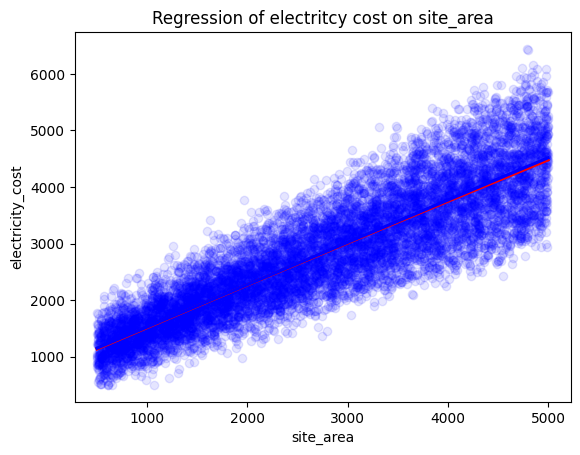

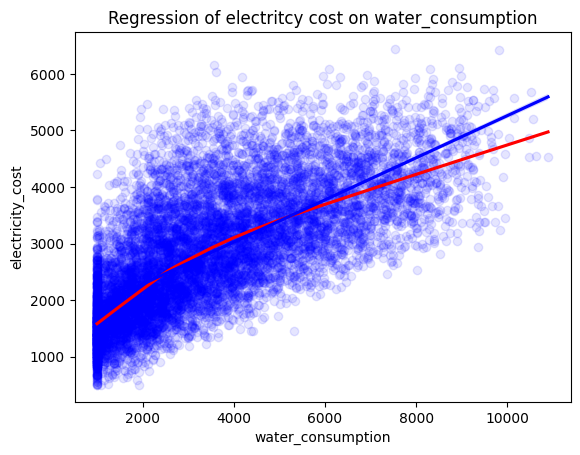

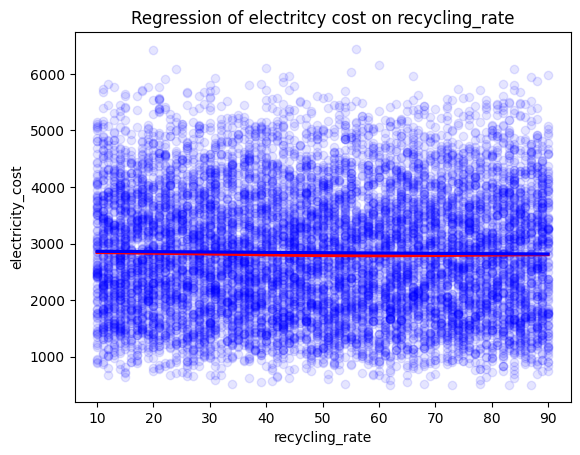

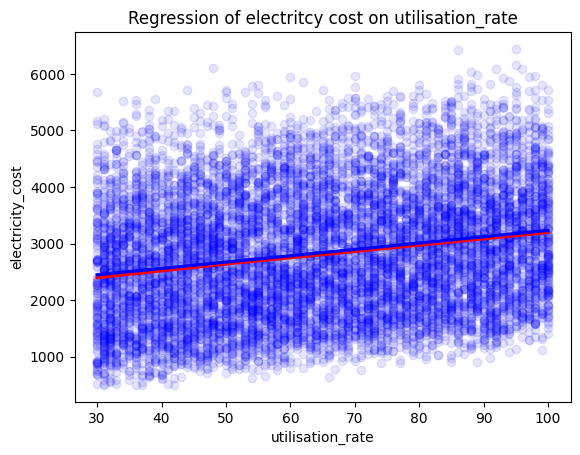

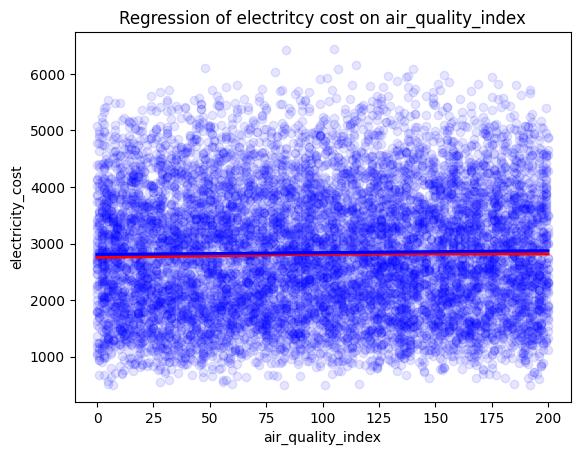

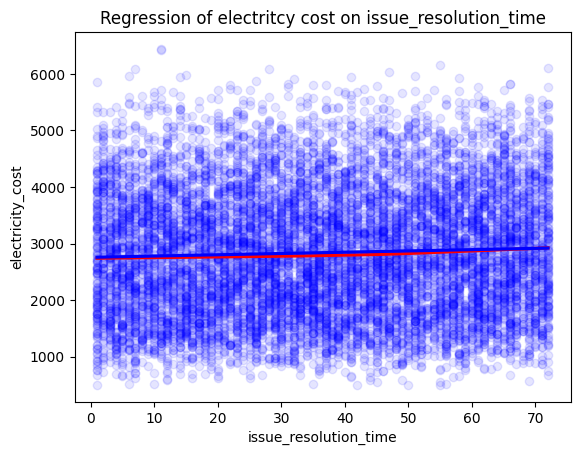

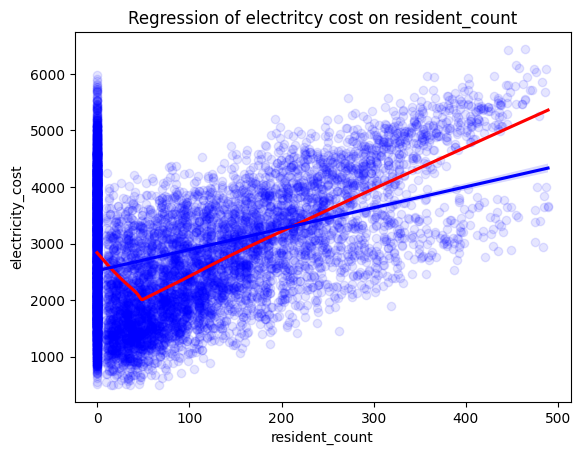

In [11]:
for feature in numerics:
    sns.regplot(df, x=feature, y="electricity_cost", lowess=True, color="red", scatter=False)
    sns.regplot(df, x=feature, y="electricity_cost", lowess=False, color="blue", scatter=True, scatter_kws={"alpha": 0.1})
    plt.title(f"Regression of electritcy cost on {feature}")
    plt.show()

In [12]:
# Findings: log-transform water_consumption; investigate trends by category
df["log_water_consumption"] = np.log(df["water_consumption"])
numerics = df.drop("electricity_cost", axis=1).select_dtypes("number").columns.to_list()
categorics = df.drop("electricity_cost", axis=1).select_dtypes(exclude="number").columns.to_list()

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in m

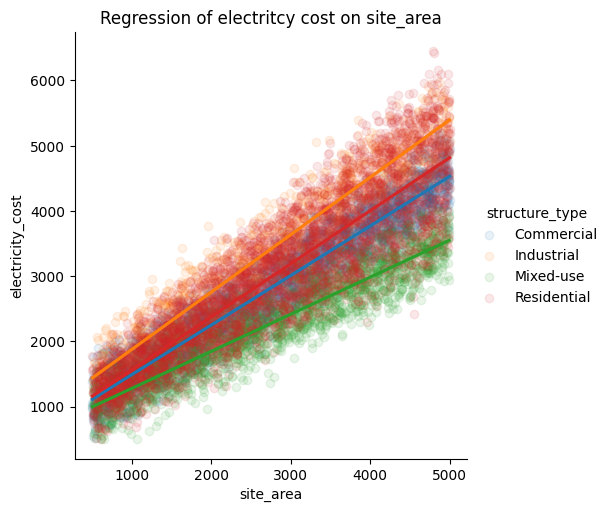

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in m

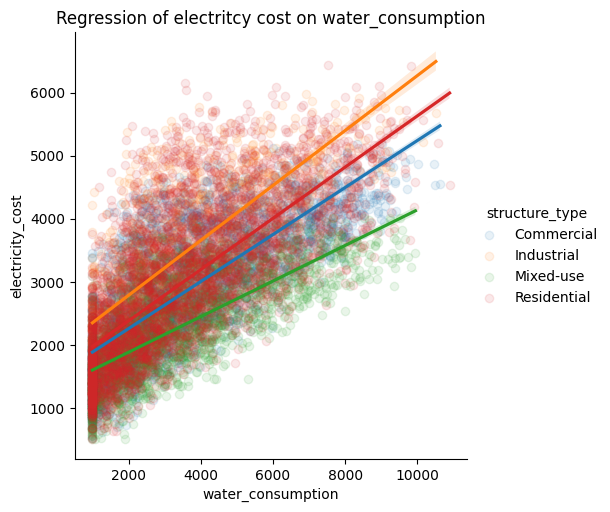

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in m

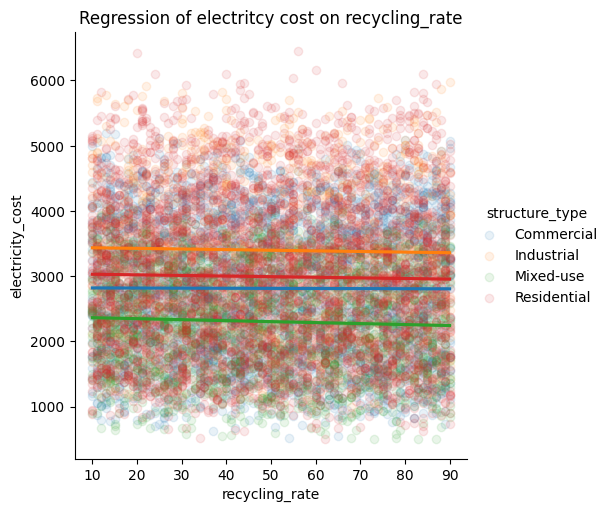

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in m

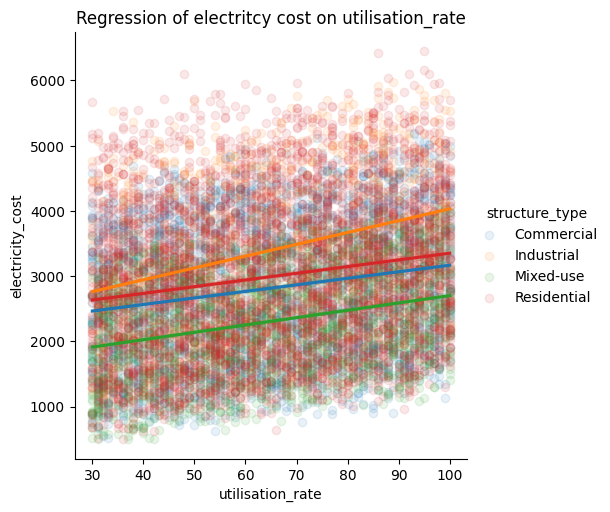

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in m

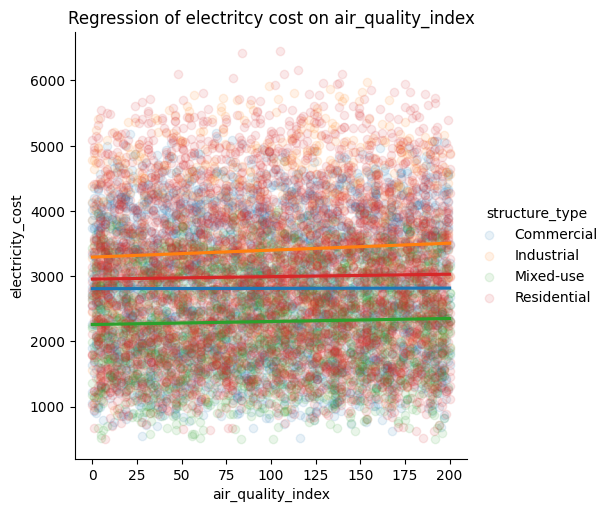

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in m

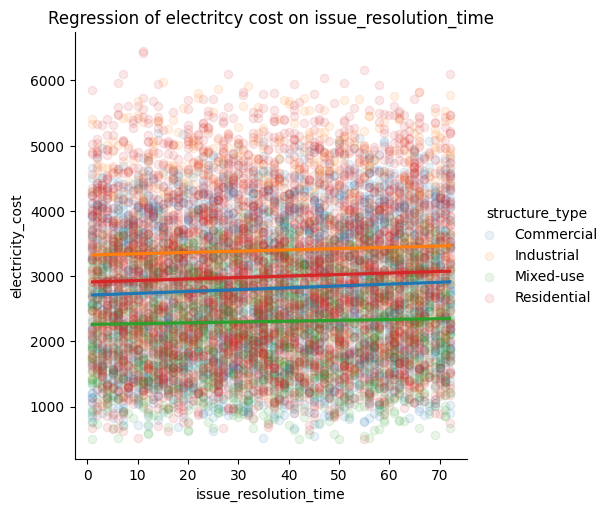

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in m

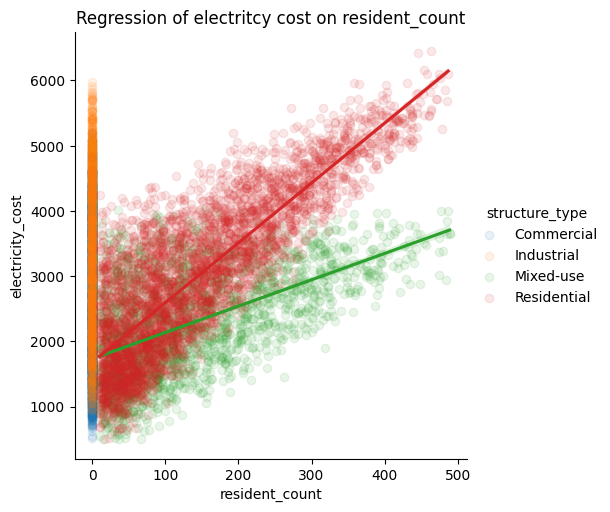

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in m

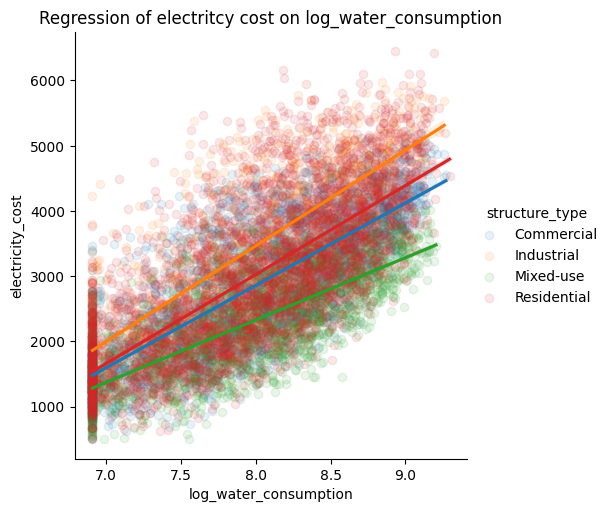

In [13]:
for feature in numerics:
    sns.lmplot(df, x=feature, y="electricity_cost", lowess=False, hue="structure_type", scatter=True, scatter_kws={"alpha": 0.1})
    plt.title(f"Regression of electritcy cost on {feature}")
    plt.show()

In [14]:
# Findings: keep log-transformed water_consumption and include interaction between resident_count and building Mixed-use and Residential

In [15]:
df["structure_type"] = df["structure_type"].replace("Mixed-use", "Mixed")

/var/folders/ll/2dw3c8w16bq4l6d2zkwh1ct40000gn/T/ipykernel_74391/2480858833.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["structure_type"] = df["structure_type"].replace("Mixed-use", "Mixed")


# Prepare features for linear modelling

In [16]:
X = df.drop(["electricity_cost", "water_consumption"], axis=1).copy()
y = df["electricity_cost"]


# Get dummies
dummies = pd.get_dummies(X["structure_type"], dtype=int, drop_first=True)
X = pd.concat([X.drop("structure_type", axis=1), dummies], axis=1)

# Train-test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [17]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
impute = X_train.columns.to_list()
X_train[impute] = imputer.fit_transform(X_train[impute])
X_test[impute] = imputer.transform(X_test[impute])

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
standardize = X_train.select_dtypes("number").drop(["Industrial", "Mixed", "Residential"], axis=1).columns.to_list()
X_train[standardize] = scaler.fit_transform(X_train[standardize])
X_test[standardize] = scaler.transform(X_test[standardize])


In [19]:
# Add constant 
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)


In [20]:
# Add interactions
X_train["Mixed:resident_count"] = X_train["Mixed"] * X_train["resident_count"]
X_train["Residential:resident_count"] = X_train["Residential"] * X_train["resident_count"]
X_test["Mixed:resident_count"] = X_test["Mixed"] * X_test["resident_count"]
X_test["Residential:resident_count"] = X_test["Residential"] * X_test["resident_count"]
X_train = X_train.drop("resident_count", axis=1)
X_test = X_test.drop("resident_count", axis=1)

In [21]:
X_train

,const,site_area,recycling_rate,utilisation_rate,air_quality_index,issue_resolution_time,log_water_consumption,Industrial,Mixed,Residential,Mixed:resident_count,Residential:resident_count
4251,1.0,-0.774185,-0.452529,0.939581,1.740320,-0.646672,-0.514295,0.0,0.0,1.0,-0.000000,-0.320671
3481,1.0,-0.426115,-1.220251,1.672869,0.259643,-0.161287,-0.317232,0.0,0.0,0.0,-0.000000,-0.000000
1066,1.0,0.059167,0.869658,1.037352,1.688668,1.489022,0.224243,1.0,0.0,0.0,-0.000000,-0.000000
3451,1.0,-0.839302,-0.580483,0.401836,0.139123,-0.258364,0.425156,0.0,0.0,1.0,-0.000000,-0.376030
685,1.0,1.030506,-0.026017,0.792923,-0.825038,-1.568904,1.586608,0.0,0.0,1.0,0.000000,2.807127
...,...,...,...,...,...,...,...,...,...,...,...,...
9367,1.0,0.618869,0.187239,-0.624768,1.516497,-0.209826,1.016476,0.0,0.0,1.0,0.000000,0.943365
6063,1.0,-1.357143,-1.476158,0.792923,0.070255,0.469713,-0.856306,0.0,1.0,0.0,-0.569787,-0.000000
3882,1.0,0.796392,-0.495180,1.086238,-1.083296,0.518252,-0.492700,0.0,0.0,1.0,-0.000000,-0.182273
1079,1.0,1.496408,-0.793739,-1.015855,-0.084700,0.081405,0.475121,0.0,0.0,0.0,-0.000000,-0.000000


<Axes: >

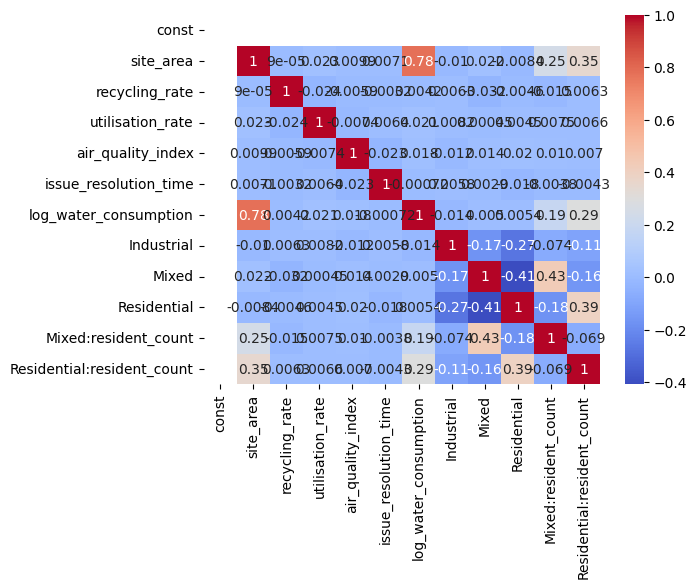

In [22]:
sns.heatmap(X_train.corr(), annot=True, cmap="coolwarm")

# Fit OLS

In [23]:
OLS = sm.OLS(y_train, X_train).fit()
print(OLS.summary())

OLS_preds = OLS.predict(X_test)
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE
print(f"MAE: {MAE(y_test, OLS_preds)}, MSE: {MSE(y_test, OLS_preds)}")

                            OLS Regression Results                            
Dep. Variable:       electricity_cost   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                 1.402e+04
Date:                Wed, 30 Jul 2025   Prob (F-statistic):               0.00
Time:                        10:14:58   Log-Likelihood:                -55363.
No. Observations:                8000   AIC:                         1.107e+05
Df Residuals:                    7988   BIC:                         1.108e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

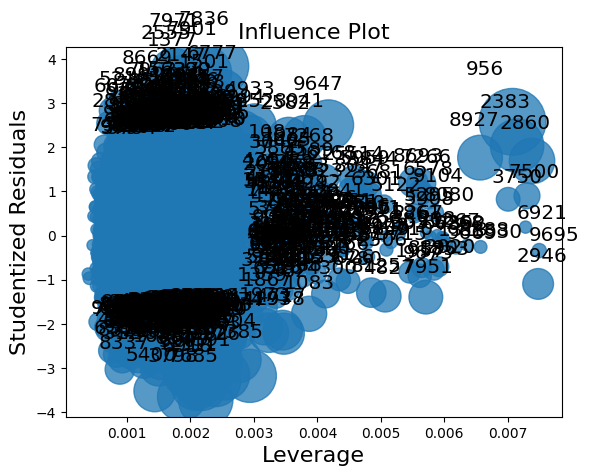

In [39]:
influence = sm.graphics.influence_plot(OLS)

In [40]:
OLS.get_influence().summary_frame()

,dfb_const,dfb_site_area,dfb_recycling_rate,dfb_utilisation_rate,dfb_air_quality_index,dfb_issue_resolution_time,dfb_log_water_consumption,dfb_Industrial,dfb_Mixed,dfb_Residential,dfb_Mixed:resident_count,dfb_Residential:resident_count,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
4251,0.000397,-0.001879,-0.002671,0.006253,0.011189,-0.003840,7.493657e-04,-0.000117,-5.144586e-04,8.690874e-03,0.000434,-0.007595,3.197752e-05,0.585979,0.001116,0.019589,0.585955,0.019588
3481,0.000209,-0.000039,-0.000137,0.000187,0.000034,-0.000021,4.181578e-07,-0.000106,-1.301604e-04,-1.564976e-04,0.000014,0.000023,8.369433e-09,0.009965,0.001010,0.000317,0.009964,0.000317
1066,0.000002,-0.000035,0.000177,0.000207,0.000352,0.000302,5.718030e-05,0.000539,7.988379e-07,3.112508e-07,-0.000004,-0.000009,5.639089e-08,0.017840,0.002122,0.000823,0.017839,0.000823
3451,0.000088,-0.008298,-0.003170,0.002196,0.000458,-0.001213,9.691529e-03,0.000027,-1.479119e-04,7.911947e-03,0.000443,-0.007220,2.191477e-05,0.502242,0.001041,0.016217,0.502219,0.016216
685,-0.000003,0.006614,0.000313,-0.004658,0.005373,0.009448,-6.698895e-03,0.000009,7.123453e-05,1.947963e-03,-0.000628,-0.021288,6.501255e-05,-0.538116,0.002687,-0.027931,-0.538092,-0.027930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9367,-0.000020,0.000253,-0.000151,0.000543,-0.001264,0.000127,-6.796776e-04,-0.000014,-2.471476e-05,-6.760767e-04,0.000106,-0.000369,3.996423e-07,-0.077027,0.000808,-0.002190,-0.077022,-0.002190
6063,0.000082,-0.002092,-0.003435,0.001947,0.000159,0.001110,8.538130e-04,-0.000055,5.828076e-03,-3.841431e-04,-0.005177,0.000842,7.340085e-06,0.219202,0.001830,0.009385,0.219189,0.009385
3882,-0.000011,-0.031093,0.006264,-0.014678,0.015160,-0.006781,2.421859e-02,0.000249,-1.574218e-03,-2.218380e-02,0.005534,0.022076,1.924794e-04,-1.258273,0.001457,-0.048060,-1.258319,-0.048062
1079,0.001022,0.001080,-0.000473,-0.000584,-0.000030,0.000022,-5.917181e-04,-0.000505,-5.246244e-04,-5.800317e-04,-0.000264,-0.000351,2.350046e-07,0.049593,0.001145,0.001679,0.049590,0.001679


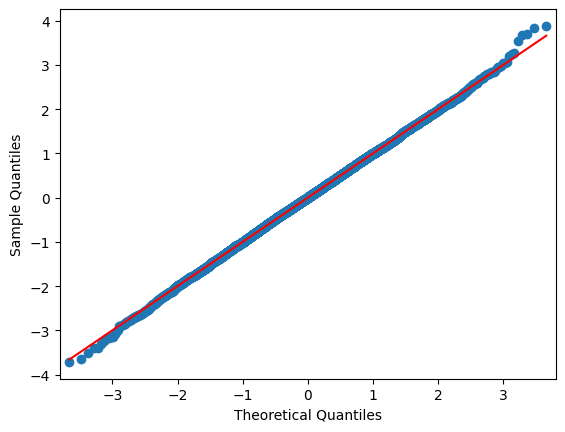

In [24]:
qq = sm.qqplot(OLS.resid_pearson, line="s")

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


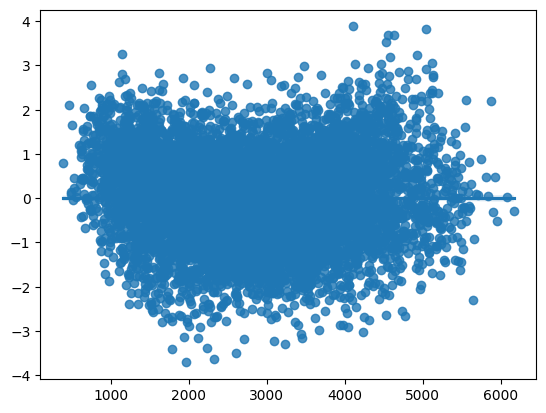

In [25]:
# Plot fitted values against residuals
plot = sns.regplot(x=OLS.fittedvalues, y=OLS.resid_pearson)

In [26]:
# Fit Gamma GLM
Gamma = sm.GLM(y_train, X_train, sm.families.Gamma(sm.families.links.Log())).fit()
print(Gamma.summary())

Gamma_preds = Gamma.predict(X_test)
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE
print(f"MAE: {MAE(y_test, Gamma_preds)}, MSE: {MSE(y_test, Gamma_preds)}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:       electricity_cost   No. Observations:                 8000
Model:                            GLM   Df Residuals:                     7988
Model Family:                   Gamma   Df Model:                           11
Link Function:                    Log   Scale:                        0.014114
Method:                          IRLS   Log-Likelihood:                -57580.
Date:                Wed, 30 Jul 2025   Deviance:                       121.83
Time:                        10:14:58   Pearson chi2:                     113.
No. Iterations:                    13   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

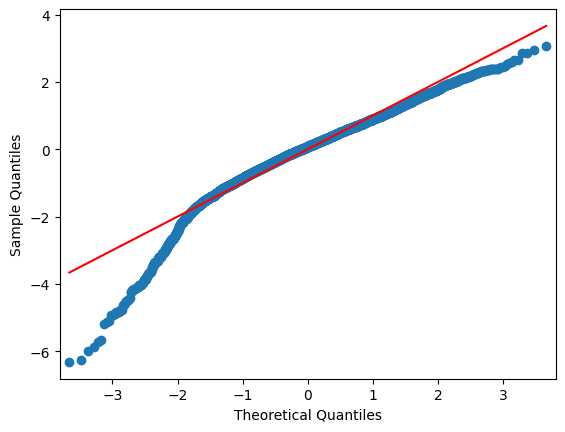

In [27]:
qq = sm.qqplot(stats.zscore(Gamma.resid_deviance), line="s")

# Fit XGB

In [30]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=1000, learning_rate=0.01).fit(X=X_train, y=y_train)

xgb_preds = xgb.predict(X_test)

print(f"MAE: {MAE(y_test, xgb_preds)}, MSE: {MSE(y_test, xgb_preds)}")

MAE: 166.88499884033203, MSE: 44346.202279527846
